## servo comunication

In [ ]:
!pip install pyserial

In [ ]:
import serial, time
#!pip install pyserial

In [ ]:
#ser.close()

**Note:** if importing `serial` causes an error, you need to install the `pyserial` module using `pip`:

`pip install pyserial`

or 

`pip3 install pyserial`

Windows users should use the Anaconda prompt.  Mac users should be able to use the terminal.

In [ ]:
print(serial)

In [ ]:
print(serial.__file__)

In [ ]:
print(serial.__version__)

In [ ]:
serial.VERSION

**Note:** if you serial version is 2.x, we might need to make changes to the code below

In [ ]:
baudrate = 115200

In [ ]:
#portname = '/dev/cu.usbmodem11301'#mac
portname = 'COM3'#windows

In [ ]:
ser = serial.Serial(portname, baudrate, timeout=5)

In [ ]:
ser.in_waiting

In [ ]:
def read_all(ser):
    out = []
    while ser.in_waiting > 0:
        data1b = ser.read(1)
        data1 = data1b.decode('utf-8')
        out.append(data1)
        
    outstr = ''.join(out)
    return outstr

In [ ]:
read_all(ser)

In [ ]:
def read_one_line(ser):
    out = []
    while ser.in_waiting > 0:
        data1b = ser.read(1)
        data1 = data1b.decode('utf-8')
        if data1 in ['\n','\r']:
            break
        out.append(data1)
        
    outstr = ''.join(out)
    return outstr

In [ ]:
read_one_line(ser)

In [ ]:
read_all(ser)

In [ ]:
def one_byte_int_to_serial_byte(int_byte):
    out_byte = int(int_byte).to_bytes(1, byteorder='big')
    return out_byte

In [ ]:
def WriteByte(ser, bytein):
    out_byte = one_byte_int_to_serial_byte(bytein)
    ser.write(out_byte)

In [ ]:
def break_into_two(breakint):
    MSB = breakint // 256
    LSB = breakint % 256
    return MSB, LSB

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import sin, cos, tan, pi
import robotics
from robotics import Rx, Ry, Rz, sind, cosd, DH, prettymat, HTx, HTz
rtd = 180/pi
dtr = pi/180

## Parameters
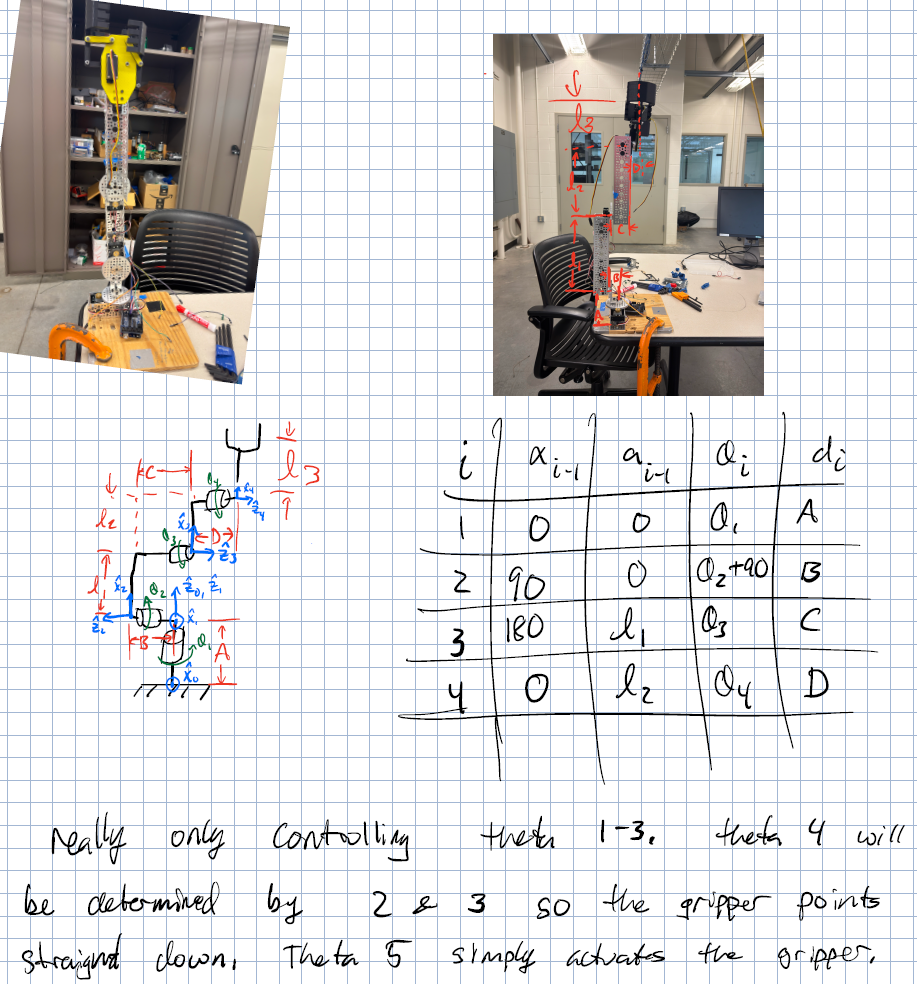

In [2]:
# measure based off sketch parameters
# units of cm
A = 3     # height of base of l1
B = 2     # offset from z1 to l1|
C = 4     # offset from l1 to l2
D = 1     # offset from l2 to center of EOAT
l1 = 24   # base link
l2 = 21.5 # tip link
l3 = 10   # gripper link

#define pick location
pickX = 10
pickY = 2
pickZ = 0

#define place location
placeX = -5
placeY = 5
placeZ = 2

#define obstical location
obstacleX = 2
obstacleY = 8

################ for reference
#T01 = DH(0,0,th1,A)
#T12 = DH(90,0,th2+90,B)
#T23 = DH(180,l1,th3,C)
#T34 = DH(0,l2,th4,D)

## Path generation

In [3]:
lift = 4  # z displacement from pick
obstacle_radius = 2 * 2.45  # 2 inches in cm
clearance = 3 # buffer distance from obstacle (cm)

#number of positions for each path
N1 = 3  # z  down into the pick
N2 = 2  # z  up above the place z
N3 = 4  # y  to below the obstacle
N4 = 10 # x  across to the place x
N5 = 10 # y  to the place y
N6 = 3  # z  down to the place
N7 = 2  # z  retract up 

z_clear = max(pickZ, placeZ) + lift                          # travel height: above place z (and above pick)
y_safe  = obstacleY - obstacle_radius - clearance            # a lane in front of (below) the obstacle

above_pick = [pickX, pickY, z_clear]                        # start: positioned above the pick
path1 = np.linspace(above_pick, [pickX, pickY, pickZ], N1)   # z  down into the pick
# ---- PAUSE: close gripper ----
path2 = np.linspace([pickX,  pickY,  pickZ],   [pickX,  pickY,  z_clear], N2)  # z  up above the place z
path3 = np.linspace([pickX,  pickY,  z_clear], [pickX,  y_safe, z_clear], N3)  # y  to below the obstacle
path4 = np.linspace([pickX,  y_safe, z_clear], [placeX, y_safe, z_clear], N4)  # x  across to the place x
path5 = np.linspace([placeX, y_safe, z_clear], [placeX, placeY, z_clear], N5)  # y  to the place y
path6 = np.linspace([placeX, placeY, z_clear], [placeX, placeY, placeZ],  N6)  # z  down to the place
# ---- PAUSE: open gripper ----
path7 = np.linspace([placeX, placeY, placeZ],  [placeX, placeY, z_clear], N7)  # z  retract up 

In [4]:
path3

array([[10.        ,  2.        ,  6.        ],
       [10.        ,  1.36666667,  6.        ],
       [10.        ,  0.73333333,  6.        ],
       [10.        ,  0.1       ,  6.        ]])

## Get from x,y,z postions to arduino servo values

In [11]:
# takes 3d coordinant and outputs required servo angles
def inverseKinematics(X, Y, Z):

    #define position as being relative to base
    P_tip_0 = np.array([X,Y,Z,1]) 

    #solve for th1
    th1 = np.arctan2(P_tip_0[1], P_tip_0[0])*rtd

    #define transform matrix to get to link 1 co-ordinants
    T01 = DH(0,0,th1,A)
    T10 = robotics.HTinv(T01)
    #get tip position relative to link 1
    P_tip_1 = T10 @ P_tip_0

    #distance from origin1 to tip
    r_squared = P_tip_1[0]**2 + P_tip_1[2]**2
    
    #law of cos for angle between links
    alpha_temp = (r_squared-l1**2-l2**2)/(-2*l1*l2)
    #print(alpha_temp)
    #alpha = np.arccos(alpha_temp)
    sin_alpha_p = np.sqrt(1-alpha_temp**2)
    sin_alpha_n = -sin_alpha_p
    alpha = np.arctan2(sin_alpha_p, alpha_temp)
    alpha_2 = np.arctan2(sin_alpha_n, alpha_temp)
    
    #vertical angle theorem for theta 2
    theta3 = 180 - alpha*rtd
    theta3_2 = 180 - alpha_2*rtd
    
    #triangle in link1 co-ordinant system for psi
    psi = np.arctan2(l2*sind(theta3),l1+l2*cosd(theta3))
    psi_2 = np.arctan2(l2*sind(theta3_2),l1+l2*cosd(theta3_2))
    
    #angle of r to x-axis
    beta = np.arctan2(P_tip_1[2], P_tip_1[0])
    
    #difference in beta and psi is theta 1
    theta2 = (beta - psi)*rtd
    theta2_2 = (beta - psi_2)*rtd

    th2 = theta2
    th3 = theta3 

    # l3 should be perpendicular to the ground at all times 
    # may need more logic depending on the values th2 and th3 are for the generated path
    th4 = 360 - 90 - th2 - th3 

    return th1, th2, th3, th4

In [10]:
# run each path through inverseKinemnatics function to get angles for each position
path1_angles = np.array([inverseKinematics(X, Y, Z) for X, Y, Z in path1])
path2_angles = np.array([inverseKinematics(X, Y, Z) for X, Y, Z in path2])
path3_angles = np.array([inverseKinematics(X, Y, Z) for X, Y, Z in path3])
path4_angles = np.array([inverseKinematics(X, Y, Z) for X, Y, Z in path4])
path5_angles = np.array([inverseKinematics(X, Y, Z) for X, Y, Z in path5])
path6_angles = np.array([inverseKinematics(X, Y, Z) for X, Y, Z in path6])
path7_angles = np.array([inverseKinematics(X, Y, Z) for X, Y, Z in path7])
path1_angles

array([[ 11.30993247, -47.22299208, 153.70952529, 163.51346679],
       [ 11.30993247, -63.58713182, 154.86115671, 178.72597511],
       [ 11.30993247, -80.00803747, 153.70952529, 196.29851218]])

In [7]:
def thetaInterpolation(th1, th2, th3, th4):
    #convert angle into arduino code
    theta_min = 0     # minimum angle
    theta_max = 180   # maximum angle
    min_new = 1000    # minimum servo value
    max_new = 2000    # maximum servo value

    #linear interpolate for the first theta value
    myint = min_new + ((th1-theta_min)*(max_new-min_new))/(theta_max-theta_min)

    #linear interpolate for the second theta value; 180 and 90 included to account for robots home position as The servo has 1000 -> theta2=90, 2000 -> theta2 = -90
    myint2 = min_new + (((180-(90+th2))-theta_min)*(max_new-min_new))/(theta_max-theta_min)

    #third theta (need to adjust once tested)
    myint3 = min_new + ((th3-theta_min)*(max_new-min_new))/(theta_max-theta_min)

    #fourth theta (need to adjust once tested)
    myint4 = min_new + ((th4-theta_min)*(max_new-min_new))/(theta_max-theta_min)

    return myint, myint2, myint3, myint4

In [8]:
# run each path_angles through thetaInterpolation function to get angles for each position in servo language
path1_servo = np.array([thetaInterpolation(th1, th2, th3, th4) for th1, th2, th3, th4 in path1_angles])
path2_servo = np.array([thetaInterpolation(th1, th2, th3, th4) for th1, th2, th3, th4 in path2_angles])
path3_servo = np.array([thetaInterpolation(th1, th2, th3, th4) for th1, th2, th3, th4 in path3_angles])
path4_servo = np.array([thetaInterpolation(th1, th2, th3, th4) for th1, th2, th3, th4 in path4_angles])
path5_servo = np.array([thetaInterpolation(th1, th2, th3, th4) for th1, th2, th3, th4 in path5_angles])
path6_servo = np.array([thetaInterpolation(th1, th2, th3, th4) for th1, th2, th3, th4 in path6_angles])
path7_servo = np.array([thetaInterpolation(th1, th2, th3, th4) for th1, th2, th3, th4 in path7_angles])

path1_servo

array([[1062.83295819, 1762.349956  , 1853.94180715, 1908.40814886],
       [1062.83295819, 1853.26184344, 1860.33975948, 1992.92208396],
       [1062.83295819, 1944.48909706, 1853.94180715, 2090.54728991]])

## logic to send paths to arduino